# RAPPORT - Analyse de logs

Ikram Sihdoum 300146418

## Présentation
Ce projet consiste à analyser un fichier de logs web afin d'extraire des informations utiles sur l'activité d'un site.

Les éléments analysés sont :
- le nombre total de requêtes
- les adresses IP les plus actives
- les URLs les plus consultées
- les codes de statut HTTP observés

## Outils utilisés
- Python
- PowerShell
- Jupyter Notebook
- pandas
- matplotlib

In [1]:
import re
from collections import Counter
from pathlib import Path

log_file = Path("data/sample.log")

ips = []
urls = []
statuses = []

pattern = re.compile(
    r'(?P<ip>\d+\.\d+\.\d+\.\d+).+"(?:GET|POST)\s(?P<url>\S+)\sHTTP/[\d.]+"\s(?P<status>\d{3})'
)

with open(log_file, "r") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            ips.append(match.group("ip"))
            urls.append(match.group("url"))
            statuses.append(match.group("status"))

print("Analyse terminée")
print("Nombre total de requêtes :", len(urls))

Analyse terminée
Nombre total de requêtes : 10


In [2]:
ip_counter = Counter(ips)
url_counter = Counter(urls)
status_counter = Counter(statuses)

print("Top 3 IP :", ip_counter.most_common(3))
print("Top 3 URLs :", url_counter.most_common(3))
print("Codes HTTP :", status_counter)

Top 3 IP : [('192.168.1.10', 4), ('192.168.1.11', 2), ('192.168.1.12', 2)]
Top 3 URLs : [('/index.html', 5), ('/products.html', 2), ('/about.html', 1)]
Codes HTTP : Counter({'200': 7, '404': 1, '500': 1, '403': 1})


In [3]:
import sys
!{sys.executable} -m pip install pandas

Defaulting to user installation because normal site-packages is not writeable


In [4]:
import pandas as pd

df = pd.DataFrame({
    "IP": ips,
    "URL": urls,
    "Status": statuses
})

df

,IP,URL,Status
0,192.168.1.10,/index.html,200
1,192.168.1.11,/about.html,200
2,192.168.1.10,/contact.html,404
3,192.168.1.12,/index.html,200
4,192.168.1.10,/index.html,200
5,192.168.1.13,/login,500
6,192.168.1.11,/index.html,200
7,192.168.1.12,/products.html,200
8,192.168.1.14,/index.html,403
9,192.168.1.10,/products.html,200


In [5]:
print("Nombre de requêtes par IP :")
print(df["IP"].value_counts())

print("\nNombre de requêtes par URL :")
print(df["URL"].value_counts())

print("\nNombre par code HTTP :")
print(df["Status"].value_counts())

Nombre de requêtes par IP :
IP
192.168.1.10    4
192.168.1.11    2
192.168.1.12    2
192.168.1.13    1
192.168.1.14    1
Name: count, dtype: int64

Nombre de requêtes par URL :
URL
/index.html       5
/products.html    2
/about.html       1
/contact.html     1
/login            1
Name: count, dtype: int64

Nombre par code HTTP :
Status
200    7
404    1
500    1
403    1
Name: count, dtype: int64


## Analyse des résultats

Les résultats montrent quelles adresses IP effectuent le plus de requêtes.  
Cela permet d’identifier les clients les plus actifs.

L’analyse des URLs permet de voir quelles pages sont les plus consultées.

Les codes HTTP permettent de détecter les erreurs :
- 200 : succès
- 403 : accès interdit
- 404 : page non trouvée
- 500 : erreur interne du serveur

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


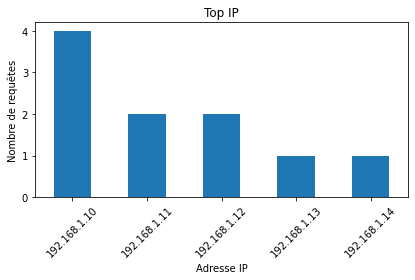

In [6]:
import matplotlib.pyplot as plt

df["IP"].value_counts().head(5).plot(kind="bar")
plt.title("Top IP")
plt.xlabel("Adresse IP")
plt.ylabel("Nombre de requêtes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

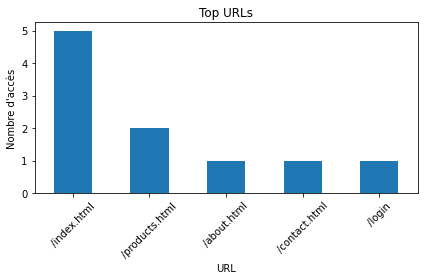

In [7]:
df["URL"].value_counts().head(5).plot(kind="bar")
plt.title("Top URLs")
plt.xlabel("URL")
plt.ylabel("Nombre d'accès")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

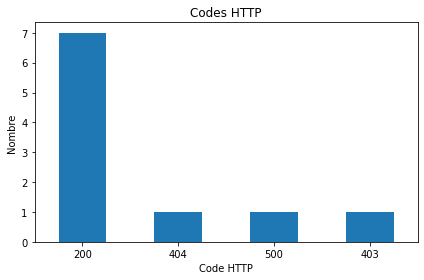

In [8]:
df["Status"].value_counts().plot(kind="bar")
plt.title("Codes HTTP")
plt.xlabel("Code HTTP")
plt.ylabel("Nombre")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()